In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [2]:
df = pd.read_csv(r"C:\Users\tanay\Downloads\googl_data_2020_2025.csv")

print(df.head())
print(df.info())

                       Price    Adj Close        Close         High  \
0                     Ticker        GOOGL        GOOGL        GOOGL   
1                       Date          NaN          NaN          NaN   
2  2020-01-02 00:00:00+00:00  68.18682098  68.43399811  68.43399811   
3  2020-01-03 00:00:00+00:00  67.83010101   68.0759964      68.6875   
4  2020-01-06 00:00:00+00:00  69.63805389  69.89050293  69.91600037   

           Low         Open    Volume  
0        GOOGL        GOOGL     GOOGL  
1          NaN          NaN       NaN  
2  67.32450104  67.42050171  27278000  
3  67.36599731  67.40000153  23408000  
4  67.55000305  67.58149719  46768000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1260 non-null   object
 1   Adj Close  1259 non-null   object
 2   Close      1259 non-null   object
 3   High       1259 non-null   

In [3]:
# Remove invalid top rows
df = df.iloc[2:]

# Convert Open column into numeric
df['Open'] = pd.to_numeric(df['Open'])

# Take Open price column
data = df['Open'].values.reshape(-1,1)

print(data[:5])

[[67.42050171]
 [67.40000153]
 [67.58149719]
 [70.02300262]
 [69.74099731]]


In [4]:
scaler = MinMaxScaler(feature_range=(0,1))

data_scaled = scaler.fit_transform(data)

print(data_scaled[:5])

[[0.10109984]
 [0.1009579 ]
 [0.10221452]
 [0.11911877]
 [0.11716625]]


In [5]:
train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

print(len(train_data))
print(len(test_data))

1006
252


In [6]:
def create_dataset(dataset):

    X = []
    y = []

    for i in range(60, len(dataset)):
        
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [7]:
X_train, y_train = create_dataset(train_data)

X_test, y_test = create_dataset(test_data)

print(X_train.shape)
print(y_train.shape)

(946, 60)
(946,)


In [8]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

print(X_train.shape)
print(X_test.shape)

(946, 60, 1)
(192, 60, 1)


In [9]:
model = Sequential()

model.add(
    SimpleRNN(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

model.add(SimpleRNN(50))

model.add(Dense(1))

C:\Users\tanay\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 50)              │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.0184
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0012
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 8.4226e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 7.5785e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 8.1141e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 6.2079e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 5.5931e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 5.4380e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 5.5683e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 5.4540e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 4.6467e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 4.7591e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 4.6680e-04
Epoch 15/20
30/30 ━━━━━━━━

In [12]:
predicted = model.predict(X_test)

predicted = scaler.inverse_transform(predicted)

real = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


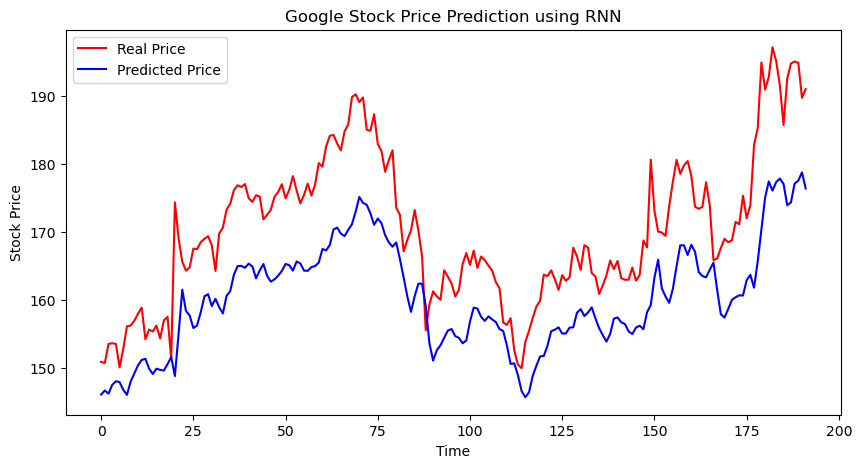

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    real,
    color='red',
    label='Real Price'
)

plt.plot(
    predicted,
    color='blue',
    label='Predicted Price'
)

plt.title("Google Stock Price Prediction using RNN")

plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

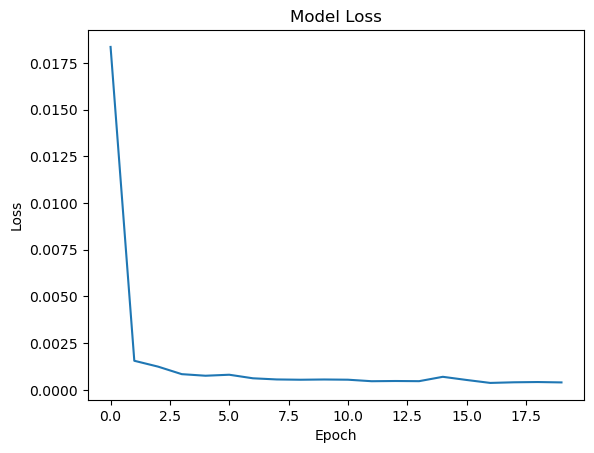

In [14]:
plt.plot(history.history['loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()